# 08 — Distilled RoBERTa: Full 1.8M Training with Teacher Soft Labels

**Goal**: Retrain RoBERTa on the **full 1.8M dataset** using a hybrid loss — the 25K samples that have teacher soft labels from NB07 get a distillation loss, while the remaining 1.775M get standard CE.

**Why this should fix the hard classes**: Debt Mgmt had 48.5% misclassification because the model only saw hard "Debt Mgmt" labels. The teacher's soft distributions teach the student where the boundaries actually lie.

**The hybrid loss**:
- 25K samples WITH teacher probs → `α × CE(hard) + (1-α) × T² × KL(soft)`
- 1.775M samples WITHOUT teacher probs → `CE(hard, class_weights)` (same as NB06a)

**Config**: Same as NB06a — max_len=384, lr=2e-5, warmup=10%, fp16, pre-tokenize + dynamic padding.

**Time estimate**: ~9 hrs/epoch × 4 epochs = ~36 hrs (run over a weekend). Early stopping may cut to ~27 hrs.

**Hardware**: NVIDIA RTX 4060 8 GB · 64 GB RAM · Windows 11

In [1]:
import os, sys, time, json, pickle, warnings, gc, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    bf16_ok  = torch.cuda.is_bf16_supported()
    print(f"GPU: {gpu_name}  ({gpu_mem:.1f} GB)  bf16={'✓' if bf16_ok else '✗'}")
else:
    print("⚠️  No GPU")

print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"OS: {sys.platform}")

GPU: NVIDIA GeForce RTX 4060 Laptop GPU  (8.0 GB)  bf16=✓
Device: cuda
PyTorch: 2.10.0+cu126
Transformers: 5.3.0
OS: win32


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION                                                  ║
# ╚══════════════════════════════════════════════════════════════════╝

MODEL_NAME       = "roberta-base"
MAX_SEQ_LEN      = 384
LEARNING_RATE    = 2e-5
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.1
BATCH_SIZE       = 16
GRAD_ACCUM       = 2         # effective batch = 32
GRAD_CHECKPOINT  = True

MAX_EPOCHS       = 4         # from RoBERTa scouting (peaked epoch 3)
PATIENCE         = 3

USE_BF16 = False
USE_FP16 = True

# ── Distillation hyperparameters ──
ALPHA            = 0.5       # balance: 0.5 = equal weight hard/soft
TEMPERATURE      = 3.0       # soften distributions to reveal class structure

# ── Full training data — no subsampling ──
MAX_TRAIN_SAMPLES = None
EVAL_SUBSAMPLE    = 50_000

NUM_WORKERS = 0 if sys.platform == "win32" else 4

# ── Paths ──
ROOT           = Path("..").resolve()
PROCESSED      = ROOT / "data" / "processed"
OUTPUT_DIR     = ROOT / "models" / "roberta_distilled"
FIG_DIR        = ROOT / "reports" / "figures" / "nb06d"
DISTILL_DIR    = ROOT / "models" / "distillation"
ROBERTA_ND_DIR = ROOT / "models" / "roberta_full"  # non-distilled baseline

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model:          {MODEL_NAME}")
print(f"Output:         {OUTPUT_DIR}")
print(f"Distill alpha:  {ALPHA}")
print(f"Temperature:    {TEMPERATURE}")
print(f"Max epochs:     {MAX_EPOCHS} (early stop patience={PATIENCE})")
print(f"Training data:  FULL 1.8M (hybrid loss)")

Model:          roberta-base
Output:         C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\roberta_distilled
Distill alpha:  0.5
Temperature:    3.0
Max epochs:     4 (early stop patience=3)
Training data:  FULL 1.8M (hybrid loss)


## 1 · Load Teacher Soft Labels

In [3]:
# ── Load teacher outputs from NB07 ──
teacher_probs_raw = np.load(DISTILL_DIR / "teacher_probs.npy")

with open(DISTILL_DIR / "teacher_metadata.json") as f:
    teacher_meta = json.load(f)

print(f"Teacher model:     {teacher_meta['teacher_model']}")
print(f"Extraction method: {teacher_meta['extraction_method']}")
print(f"Teacher samples:   {teacher_probs_raw.shape[0]:,}")
print(f"Failure rate:      {teacher_meta['failure_rate']:.1%}")
print(f"Shape:             {teacher_probs_raw.shape}")

# Spot check
print(f"\nSpot check (first 3 distributions):")
for i in range(3):
    top = np.argsort(teacher_probs_raw[i])[-2:][::-1]
    print(f"  Sample {i}: top2 = class {top[0]} ({teacher_probs_raw[i][top[0]]:.3f}), "
          f"class {top[1]} ({teacher_probs_raw[i][top[1]]:.3f})")

Teacher model:     facebook/bart-large-mnli
Extraction method: zero_shot_classification_pipeline
Teacher samples:   25,000
Failure rate:      0.0%
Shape:             (25000, 10)

Spot check (first 3 distributions):
  Sample 0: top2 = class 0 (0.566), class 5 (0.207)
  Sample 1: top2 = class 0 (0.488), class 5 (0.117)
  Sample 2: top2 = class 0 (0.872), class 2 (0.035)


## 2 · Load Data & Rebuild Teacher Index Mapping

In [4]:
train_df = pd.read_parquet(PROCESSED / "train.parquet")
val_df   = pd.read_parquet(PROCESSED / "val.parquet")
test_df  = pd.read_parquet(PROCESSED / "test.parquet")

with open(PROCESSED / "label_encoders.pkl", "rb") as f:
    label_encoders = pickle.load(f)

product_names = list(label_encoders["product_encoder"].classes_)
n_classes = len(product_names)

SHORT = {
    "Credit reporting or other personal consumer reports": "Credit Report",
    "Debt collection": "Debt Collect",
    "Credit card": "Credit Card",
    "Checking or savings account": "Bank Acct",
    "Mortgage": "Mortgage",
    "Money transfer, virtual currency, or money service": "Money Xfer",
    "Student loan": "Student Loan",
    "Vehicle loan or lease": "Vehicle Loan",
    "Payday loan, title loan, personal loan, or advance loan": "Payday/Pers",
    "Debt or credit management": "Debt Mgmt",
}
short_labels = [SHORT.get(n, n) for n in product_names]

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}  Classes: {n_classes}")

Train: 1,813,849  Val: 331,178  Test: 274,065  Classes: 10


In [5]:
# ── Recreate the EXACT teacher subsample to get original indices ──
# Must match NB07: teacher_stratified_sample(train_df, 25000, min_per_class=200, seed=42)
# We reproduce the logic WITHOUT reset_index to capture original positions.

def _recreate_teacher_indices(df, total_samples=25000, min_per_class=200, seed=42):
    """Reproduce NB06c's sampling to recover which rows got teacher labels."""
    groups = df.groupby("product_id")
    parts = []

    for cls_id, group in groups:
        n_available = len(group)
        n_take = min(min_per_class, n_available)
        parts.append(group.sample(n=n_take, random_state=seed))

    guaranteed = pd.concat(parts)
    remaining_budget = total_samples - len(guaranteed)

    if remaining_budget > 0:
        leftover = df.drop(guaranteed.index)
        frac = remaining_budget / len(leftover)
        extra = leftover.groupby("product_id", group_keys=False).apply(
            lambda x: x.sample(frac=min(frac, 1.0), random_state=seed)
        )
        result = pd.concat([guaranteed, extra])
    else:
        result = guaranteed

    # DO NOT reset_index — we need the original positions
    return result


teacher_sub_recreated = _recreate_teacher_indices(train_df, total_samples=25000, min_per_class=200)
teacher_original_positions = teacher_sub_recreated.index.tolist()

print(f"Recreated teacher subsample: {len(teacher_original_positions):,} rows")
print(f"  Matches teacher_probs shape: {len(teacher_original_positions) == teacher_probs_raw.shape[0]}")

# Verify alignment: check a few labels match
teacher_labels_recreated = teacher_sub_recreated["product_id"].values
# The teacher_probs argmax should roughly agree with the true labels
teacher_preds = teacher_probs_raw.argmax(axis=1)
alignment_acc = (teacher_preds == teacher_labels_recreated).mean()
print(f"  Alignment check (teacher argmax vs true label): {alignment_acc:.1%}")
print(f"  (Should be >50% — teacher isn't perfect but should be correlated)")

assert len(teacher_original_positions) == teacher_probs_raw.shape[0], \
    f"Size mismatch: {len(teacher_original_positions)} positions vs {teacher_probs_raw.shape[0]} probs"

# Build the lookup dict: {row_position_in_train_df: soft_probs_array}
teacher_probs_dict = {}
for local_idx, orig_pos in enumerate(teacher_original_positions):
    teacher_probs_dict[orig_pos] = teacher_probs_raw[local_idx]

print(f"\n  Teacher probs dict: {len(teacher_probs_dict):,} entries")
print(f"  Coverage: {len(teacher_probs_dict)/len(train_df):.2%} of training data has soft labels")

del teacher_sub_recreated
gc.collect()

Recreated teacher subsample: 25,000 rows
  Matches teacher_probs shape: True
  Alignment check (teacher argmax vs true label): 72.5%
  (Should be >50% — teacher isn't perfect but should be correlated)

  Teacher probs dict: 25,000 entries
  Coverage: 1.38% of training data has soft labels


100

In [6]:
# ── Class weights from full training set ──
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(n_classes),
    y=train_df["product_id"].values,
)

print("Class weights (full 1.8M):")
for sl, w in zip(short_labels, class_weights):
    print(f"  {sl:15s}  {w:.4f}")

Class weights (full 1.8M):
  Bank Acct        1.3967
  Credit Card      1.0737
  Credit Report    0.1896
  Debt Collect     0.6817
  Debt Mgmt        98.2583
  Money Xfer       3.7512
  Mortgage         1.4554
  Payday/Pers      5.2452
  Student Loan     3.7972
  Vehicle Loan     5.1547


In [7]:
# ── Val subsample for during-training eval ──
def stratified_sample(df, max_samples, seed=42):
    if max_samples is None or len(df) <= max_samples:
        return df.copy()
    frac = max_samples / len(df)
    sampled = df.groupby("product_id", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    )
    return sampled.reset_index(drop=True)


val_sub = stratified_sample(val_df, EVAL_SUBSAMPLE)
print(f"Val eval subsample: {len(val_sub):,} / {len(val_df):,}")

Val eval subsample: 50,002 / 331,178


## 3 · Pre-Tokenize

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {tokenizer.__class__.__name__}  vocab={tokenizer.vocab_size:,}")

Tokenizer: RobertaTokenizer  vocab=50,265


In [9]:
def batch_tokenize(texts, tokenizer, max_len, batch_size=10000, desc="Tokenizing"):
    all_input_ids = []
    all_attention_masks = []
    for start in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch_texts = texts[start : start + batch_size]
        enc = tokenizer(
            batch_texts,
            truncation=True,
            max_length=max_len,
            padding=False,
            return_attention_mask=True,
            return_token_type_ids=False,
        )
        all_input_ids.extend(enc["input_ids"])
        all_attention_masks.extend(enc["attention_mask"])
    return all_input_ids, all_attention_masks


print("Pre-tokenizing full training set (1.8M)...\n")

t0 = time.time()
train_input_ids, train_attn_masks = batch_tokenize(
    train_df["narrative"].fillna("").tolist(), tokenizer, MAX_SEQ_LEN,
    desc="Train (1.8M)"
)
train_labels = train_df["product_id"].values.tolist()
# CRITICAL: track original row positions for teacher probs lookup
train_positions = list(range(len(train_df)))
print(f"  Train tokenized: {len(train_input_ids):,} in {(time.time()-t0)/60:.1f} min")

t0 = time.time()
val_sub_ids, val_sub_masks = batch_tokenize(
    val_sub["narrative"].fillna("").tolist(), tokenizer, MAX_SEQ_LEN,
    desc="Val subsample"
)
val_sub_labels = val_sub["product_id"].values.tolist()
print(f"  Val subsample tokenized: {len(val_sub_ids):,} in {(time.time()-t0)/60:.1f} min")

# Count how many training samples have teacher probs
n_with_teacher = sum(1 for pos in train_positions if pos in teacher_probs_dict)
print(f"\n  Training samples with teacher probs: {n_with_teacher:,} / {len(train_positions):,} ({n_with_teacher/len(train_positions):.2%})")

Pre-tokenizing full training set (1.8M)...



Train (1.8M):   0%|          | 0/182 [00:00<?, ?it/s]

  Train tokenized: 1,813,849 in 6.2 min


Val subsample:   0%|          | 0/6 [00:00<?, ?it/s]

  Val subsample tokenized: 50,002 in 0.3 min

  Training samples with teacher probs: 25,000 / 1,813,849 (1.38%)


In [10]:
# Keep val/test for post-training evaluation
val_full_texts  = val_df["narrative"].fillna("").tolist()
val_full_labels = val_df["product_id"].values.tolist()
test_texts      = test_df["narrative"].fillna("").tolist()
test_labels     = test_df["product_id"].values.tolist()
full_train_size = len(train_df)

del train_df, val_df, test_df, val_sub
gc.collect()
print("DataFrames freed.")

DataFrames freed.


## 4 · Dataset & Collator

In [11]:
class DistillationDataset(Dataset):
    """Pre-tokenized dataset that also returns sample position for teacher lookup."""

    def __init__(self, input_ids_list, attn_mask_list, labels, positions):
        self.input_ids  = input_ids_list
        self.attn_masks = attn_mask_list
        self.labels     = labels
        self.positions  = positions  # original row positions in train.parquet

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      torch.tensor(self.input_ids[idx],  dtype=torch.long),
            "attention_mask": torch.tensor(self.attn_masks[idx], dtype=torch.long),
            "labels":         torch.tensor(self.labels[idx],     dtype=torch.long),
            "position":       torch.tensor(self.positions[idx],  dtype=torch.long),
        }


class PreTokenizedDataset(Dataset):
    """Standard pre-tokenized dataset (for val/test — no position tracking needed)."""

    def __init__(self, input_ids_list, attn_mask_list, labels):
        self.input_ids  = input_ids_list
        self.attn_masks = attn_mask_list
        self.labels     = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      torch.tensor(self.input_ids[idx],  dtype=torch.long),
            "attention_mask": torch.tensor(self.attn_masks[idx], dtype=torch.long),
            "labels":         torch.tensor(self.labels[idx],     dtype=torch.long),
        }


train_dataset = DistillationDataset(train_input_ids, train_attn_masks, train_labels, train_positions)
val_eval_dataset = PreTokenizedDataset(val_sub_ids, val_sub_masks, val_sub_labels)

print(f"Train dataset: {len(train_dataset):,} (with position tracking)")
print(f"Val eval dataset: {len(val_eval_dataset):,}")

# Verify a sample with teacher probs
sample_pos = teacher_original_positions[0]
sample = train_dataset[sample_pos]
print(f"\nSample at position {sample_pos}:")
print(f"  Has teacher probs: {sample['position'].item() in teacher_probs_dict}")
print(f"  input_ids length: {len(sample['input_ids'])}")

Train dataset: 1,813,849 (with position tracking)
Val eval dataset: 50,002

Sample at position 368501:
  Has teacher probs: True
  input_ids length: 117


In [12]:
# ── Custom collator: pads sequences + stacks position field ──
class DistillationCollator:
    """Wraps DataCollatorWithPadding to also handle the 'position' field."""

    def __init__(self, tokenizer, max_length):
        self.base_collator = DataCollatorWithPadding(
            tokenizer=tokenizer,
            padding="longest",
            max_length=max_length,
        )

    def __call__(self, features):
        # Separate position field (not all datasets have it)
        positions = None
        if "position" in features[0]:
            positions = torch.stack([f.pop("position") for f in features])

        # Let base collator handle input_ids, attention_mask, labels
        batch = self.base_collator(features)

        # Add position back if it existed
        if positions is not None:
            batch["position"] = positions

        return batch


data_collator = DistillationCollator(tokenizer, MAX_SEQ_LEN)

# Test it
test_batch = data_collator([train_dataset[i] for i in range(4)])
print(f"Collator test:")
print(f"  input_ids shape: {test_batch['input_ids'].shape}")
print(f"  position shape:  {test_batch['position'].shape}")
print(f"  ✓ DistillationCollator working")

Collator test:
  input_ids shape: torch.Size([4, 384])
  position shape:  torch.Size([4])
  ✓ DistillationCollator working


## 5 · Model & Distillation Trainer

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=n_classes,
    problem_type="single_label_classification",
)

if GRAD_CHECKPOINT:
    model.gradient_checkpointing_enable(
        gradient_checkpointing_kwargs={"use_reentrant": False}
    )
    print("✓ Gradient checkpointing enabled")

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model: {MODEL_NAME} ({n_params:.1f}M params)")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Gradient checkpointing enabled
Model: roberta-base (124.7M params)


In [14]:
class DistillationTrainer(Trainer):
    """Hybrid trainer: distillation loss on samples with teacher probs,
    standard weighted CE on the rest.

    For samples WITH teacher soft labels:
        loss = alpha * CE(student, hard) + (1-alpha) * T^2 * KL(student_soft, teacher_soft)

    For samples WITHOUT:
        loss = CE(student, hard, class_weights)
    """

    def __init__(self, teacher_probs_dict, class_weights_np,
                 alpha=0.5, temperature=3.0, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher_probs_dict = teacher_probs_dict
        self._cw_np = class_weights_np
        self._cw_tensor = None
        self.alpha = alpha
        self.temperature = temperature

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels    = inputs.pop("labels")
        positions = inputs.pop("position", None)
        outputs   = model(**inputs)
        logits    = outputs.logits

        # Lazy device transfer for class weights
        if self._cw_tensor is None or self._cw_tensor.device != logits.device:
            self._cw_tensor = torch.tensor(
                self._cw_np, dtype=torch.float32, device=logits.device
            )

        # ── Split batch into samples WITH and WITHOUT teacher probs ──
        if positions is not None:
            pos_list = positions.cpu().tolist()
            has_teacher_mask = torch.tensor(
                [p in self.teacher_probs_dict for p in pos_list],
                dtype=torch.bool, device=logits.device
            )
        else:
            has_teacher_mask = torch.zeros(len(labels), dtype=torch.bool, device=logits.device)

        n_with = has_teacher_mask.sum().item()
        n_without = len(labels) - n_with

        total_loss = torch.tensor(0.0, device=logits.device)

        # ── Samples WITHOUT teacher probs → standard CE ──
        if n_without > 0:
            no_teacher_logits = logits[~has_teacher_mask]
            no_teacher_labels = labels[~has_teacher_mask]
            ce_loss = nn.CrossEntropyLoss(weight=self._cw_tensor)(
                no_teacher_logits, no_teacher_labels
            )
            total_loss = total_loss + ce_loss * (n_without / len(labels))

        # ── Samples WITH teacher probs → distillation loss ──
        if n_with > 0:
            teacher_idx = [i for i, p in enumerate(pos_list) if p in self.teacher_probs_dict]
            teacher_batch = torch.tensor(
                [self.teacher_probs_dict[pos_list[i]] for i in teacher_idx],
                dtype=torch.float32, device=logits.device
            )

            dist_logits = logits[has_teacher_mask]
            dist_labels = labels[has_teacher_mask]

            # Hard loss (CE with class weights)
            hard_loss = nn.CrossEntropyLoss(weight=self._cw_tensor)(dist_logits, dist_labels)

            # Soft loss (KL divergence with temperature)
            T = self.temperature
            student_log_soft = nn.functional.log_softmax(dist_logits / T, dim=-1)
            teacher_soft = nn.functional.softmax(
                torch.log(teacher_batch + 1e-8) / T, dim=-1
            )
            soft_loss = nn.KLDivLoss(reduction="batchmean")(student_log_soft, teacher_soft) * (T ** 2)

            # Combined distillation loss
            distill_loss = self.alpha * hard_loss + (1 - self.alpha) * soft_loss
            total_loss = total_loss + distill_loss * (n_with / len(labels))

        return (total_loss, outputs) if return_outputs else total_loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average="macro")
    accuracy = (preds == labels).mean()
    return {"macro_f1": macro_f1, "accuracy": accuracy}


print(f"✓ DistillationTrainer defined")
print(f"  alpha={ALPHA}, temperature={TEMPERATURE}")
print(f"  {len(teacher_probs_dict):,} samples get soft labels, rest get standard CE")

✓ DistillationTrainer defined
  alpha=0.5, temperature=3.0
  25,000 samples get soft labels, rest get standard CE


## 6 · Training Arguments

In [15]:
steps_per_epoch = len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM)
eval_steps      = steps_per_epoch
save_steps      = eval_steps
total_steps     = steps_per_epoch * MAX_EPOCHS

print(f"Training schedule:")
print(f"  Train samples:     {len(train_dataset):>10,}  (full 1.8M)")
print(f"  With teacher:      {len(teacher_probs_dict):>10,}  ({len(teacher_probs_dict)/len(train_dataset):.2%})")
print(f"  Without teacher:   {len(train_dataset)-len(teacher_probs_dict):>10,}")
print(f"  Effective batch:   {BATCH_SIZE * GRAD_ACCUM}")
print(f"  Steps/epoch:       {steps_per_epoch:>10,}")
print(f"  Eval every:        {eval_steps:>10,} steps (1 epoch)")
print(f"  Max epochs:        {MAX_EPOCHS}")
print(f"  Early stop:        patience={PATIENCE}")
print(f"  Distill alpha:     {ALPHA}")
print(f"  Temperature:       {TEMPERATURE}")

Training schedule:
  Train samples:      1,813,849  (full 1.8M)
  With teacher:          25,000  (1.38%)
  Without teacher:    1,788,849
  Effective batch:   32
  Steps/epoch:           56,682
  Eval every:            56,682 steps (1 epoch)
  Max epochs:        4
  Early stop:        patience=3
  Distill alpha:     0.5
  Temperature:       3.0


In [16]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "checkpoints"),

    num_train_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",

    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=GRAD_ACCUM,

    bf16=USE_BF16,
    fp16=USE_FP16,

    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=save_steps,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=max(steps_per_epoch // 10, 100),
    report_to="none",

    seed=SEED,
    dataloader_num_workers=NUM_WORKERS,
    dataloader_pin_memory=(NUM_WORKERS > 0),
    remove_unused_columns=False,
)

trainer = DistillationTrainer(
    teacher_probs_dict=teacher_probs_dict,
    class_weights_np=class_weights,
    alpha=ALPHA,
    temperature=TEMPERATURE,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
)

print(f"✓ Trainer ready — distillation ON")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✓ Trainer ready — distillation ON


## 7 · Train

This is the long run. ~36 hours for 4 epochs on 1.8M. Run over a weekend.

In [17]:
print(f"{'='*70}")
print(f"  STARTING DISTILLED TRAINING — {MODEL_NAME}")
print(f"  {len(train_dataset):,} train (full 1.8M) · {len(val_eval_dataset):,} val")
print(f"  {len(teacher_probs_dict):,} samples with teacher soft labels")
print(f"  max {MAX_EPOCHS} epochs · alpha={ALPHA} · T={TEMPERATURE}")
print(f"  Precision={'bf16' if USE_BF16 else 'fp16'} · Dynamic padding=ON")
print(f"{'='*70}")
print(f"  ⏰ Started at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  This will take ~36 hours. Go live your life!\n")

t0 = time.time()
train_result = trainer.train()
elapsed = time.time() - t0

print(f"\n{'='*70}")
print(f"  TRAINING COMPLETE")
print(f"  Total time: {elapsed/3600:.1f} hours ({elapsed/60:.1f} min)")
print(f"  Finished at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Final train loss: {train_result.training_loss:.4f}")
print(f"{'='*70}")

eval_logs = [l for l in trainer.state.log_history if "eval_macro_f1" in l]
if eval_logs:
    best_log   = max(eval_logs, key=lambda x: x["eval_macro_f1"])
    best_step  = best_log["step"]
    best_f1    = best_log["eval_macro_f1"]
    best_epoch = best_step / steps_per_epoch
    stopped_at = eval_logs[-1]["step"] / steps_per_epoch

    print(f"\n  Best eval macro-F1: {best_f1:.4f} at step {best_step:,} (≈ epoch {best_epoch:.1f})")
    print(f"  Stopped at: ≈ epoch {stopped_at:.1f}")
    print(f"  Non-distilled RoBERTa: 0.7252 (for comparison)")
else:
    print("  ⚠️  No eval metrics logged!")
    best_epoch = MAX_EPOCHS
    best_f1 = 0.0
    stopped_at = MAX_EPOCHS
    best_step = total_steps

  STARTING DISTILLED TRAINING — roberta-base
  1,813,849 train (full 1.8M) · 50,002 val
  25,000 samples with teacher soft labels
  max 4 epochs · alpha=0.5 · T=3.0
  Precision=fp16 · Dynamic padding=ON
  ⏰ Started at: 2026-03-20 09:26:30
  This will take ~36 hours. Go live your life!



Step,Training Loss,Validation Loss,Macro F1,Accuracy
56682,1.105150,0.437331,0.719607,0.856886
113364,0.983884,0.451036,0.731428,0.855886
170046,0.847568,0.428763,0.736873,0.862805
226728,0.756479,0.433939,0.740995,0.864345


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


  TRAINING COMPLETE
  Total time: 39.0 hours (2340.3 min)
  Finished at: 2026-03-22 00:26:48
  Final train loss: 0.9875

  Best eval macro-F1: 0.7410 at step 226,728 (≈ epoch 4.0)
  Stopped at: ≈ epoch 4.0
  Non-distilled RoBERTa: 0.7252 (for comparison)


In [18]:
trainer.args.num_train_epochs = 7
print("Continuing training from epoch 4 → 7...")
print(f"⏰ Resumed at: {time.strftime('%Y-%m-%d %H:%M:%S')}")

t0_extra = time.time()
trainer.train(resume_from_checkpoint=True)
elapsed_extra = time.time() - t0_extra
elapsed = elapsed + elapsed_extra

print(f"\nExtra training complete: {elapsed_extra/3600:.1f} hrs")
print(f"Total training time: {elapsed/3600:.1f} hrs")

# Re-extract best checkpoint info
eval_logs = [l for l in trainer.state.log_history if "eval_macro_f1" in l]
if eval_logs:
    best_log   = max(eval_logs, key=lambda x: x["eval_macro_f1"])
    best_step  = best_log["step"]
    best_f1    = best_log["eval_macro_f1"]
    best_epoch = best_step / steps_per_epoch
    stopped_at = eval_logs[-1]["step"] / steps_per_epoch
    print(f"\nBest macro-F1: {best_f1:.4f} at epoch {best_epoch:.1f}")
    print(f"Stopped at: epoch {stopped_at:.1f}")

Continuing training from epoch 4 → 7...
⏰ Resumed at: 2026-03-22 00:27:06


There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Step,Training Loss,Validation Loss,Macro F1,Accuracy
283410,0.794732,0.450605,0.734384,0.858226
340092,0.676516,0.450997,0.736758,0.862486
396774,0.627799,0.459371,0.736014,0.864145


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Extra training complete: 29.2 hrs
Total training time: 68.2 hrs

Best macro-F1: 0.7410 at epoch 4.0
Stopped at: epoch 7.0


## 8 · Full Evaluation (Val + Test)

In [19]:
print("Pre-tokenizing full val set...")
val_full_ids, val_full_masks = batch_tokenize(val_full_texts, tokenizer, MAX_SEQ_LEN, desc="Val full")
val_full_dataset = PreTokenizedDataset(val_full_ids, val_full_masks, val_full_labels)

# Need a simple collator for val/test (no position field)
simple_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding="longest", max_length=MAX_SEQ_LEN)

print("\nEvaluating on FULL validation set...")
torch.cuda.empty_cache()

# Temporarily swap collator for evaluation
trainer.data_collator = simple_collator
val_predictions = trainer.predict(val_full_dataset)
val_logits  = val_predictions.predictions
val_y_true  = val_predictions.label_ids
val_y_pred  = np.argmax(val_logits, axis=-1)
val_y_prob  = torch.softmax(torch.tensor(val_logits, dtype=torch.float32), dim=-1).numpy()

assert not np.isnan(val_logits).any(), "NaN in val logits"

val_macro_f1 = f1_score(val_y_true, val_y_pred, average="macro")
val_accuracy = (val_y_true == val_y_pred).mean()
val_weighted = f1_score(val_y_true, val_y_pred, average="weighted")
val_micro_f1 = f1_score(val_y_true, val_y_pred, average="micro")

print(f"\n{'='*50}")
print(f"  Distilled RoBERTa — FULL Validation")
print(f"{'='*50}")
print(f"  Macro-F1:    {val_macro_f1:.4f}")
print(f"  Accuracy:    {val_accuracy:.4f}")
print(f"{'='*50}")

Pre-tokenizing full val set...


Val full:   0%|          | 0/34 [00:00<?, ?it/s]


Evaluating on FULL validation set...



  Distilled RoBERTa — FULL Validation
  Macro-F1:    0.7480
  Accuracy:    0.8636


In [20]:
print("Pre-tokenizing test set...")
test_ids, test_masks = batch_tokenize(test_texts, tokenizer, MAX_SEQ_LEN, desc="Test")
test_dataset = PreTokenizedDataset(test_ids, test_masks, test_labels)

print("\nEvaluating on TEST set...")
torch.cuda.empty_cache()

test_predictions = trainer.predict(test_dataset)
test_logits  = test_predictions.predictions
test_y_true  = test_predictions.label_ids
test_y_pred  = np.argmax(test_logits, axis=-1)
test_y_prob  = torch.softmax(torch.tensor(test_logits, dtype=torch.float32), dim=-1).numpy()

assert not np.isnan(test_logits).any(), "NaN in test logits"

test_macro_f1  = f1_score(test_y_true, test_y_pred, average="macro")
test_micro_f1  = f1_score(test_y_true, test_y_pred, average="micro")
test_weighted  = f1_score(test_y_true, test_y_pred, average="weighted")
test_accuracy  = (test_y_true == test_y_pred).mean()
test_per_class = f1_score(test_y_true, test_y_pred, average=None)

# Load non-distilled baseline
nd_path = ROBERTA_ND_DIR / "roberta_full_results.json"
if nd_path.exists():
    with open(nd_path) as f:
        nd_results = json.load(f)
    nd_macro = nd_results["test_macro_f1"]
    nd_per_class = nd_results["test_per_class_f1"]
else:
    nd_macro = 0.7252
    nd_per_class = {}

print(f"\n{'='*60}")
print(f"  Distilled RoBERTa — TEST Results")
print(f"{'='*60}")
print(f"  Macro-F1:    {test_macro_f1:.4f}")
print(f"  Accuracy:    {test_accuracy:.4f}")
print(f"  Weighted-F1: {test_weighted:.4f}")
print(f"{'='*60}")
print()
print(f"  Comparison:")
print(f"    LogReg baseline:           0.7543")
print(f"    RoBERTa non-distilled:     {nd_macro:.4f}")
print(f"    RoBERTa DISTILLED (this):  {test_macro_f1:.4f}  Δ vs non-dist: {test_macro_f1 - nd_macro:+.4f}")
print()
print(classification_report(test_y_true, test_y_pred, target_names=short_labels, digits=4))

Pre-tokenizing test set...


Test:   0%|          | 0/28 [00:00<?, ?it/s]


Evaluating on TEST set...



  Distilled RoBERTa — TEST Results
  Macro-F1:    0.7496
  Accuracy:    0.8524
  Weighted-F1: 0.8531

  Comparison:
    LogReg baseline:           0.7543
    RoBERTa non-distilled:     0.7298
    RoBERTa DISTILLED (this):  0.7496  Δ vs non-dist: +0.0199

               precision    recall  f1-score   support

    Bank Acct     0.8219    0.8288    0.8253     23730
  Credit Card     0.7870    0.7843    0.7856     24237
Credit Report     0.9280    0.9003    0.9139    150438
 Debt Collect     0.7522    0.7721    0.7620     40040
    Debt Mgmt     0.6802    0.2451    0.3604      1232
   Money Xfer     0.7293    0.7592    0.7439     11277
     Mortgage     0.8811    0.9346    0.9071      7938
  Payday/Pers     0.6023    0.7427    0.6651      4516
 Student Loan     0.6994    0.8791    0.7790      3954
 Vehicle Loan     0.7012    0.8153    0.7539      6703

     accuracy                         0.8524    274065
    macro avg     0.7583    0.7661    0.7496    274065
 weighted avg     0.8558   

## 9 · Hard Class Analysis (The Whole Point)

In [21]:
# ── Did distillation fix the hard classes? ──
print(f"{'='*70}")
print(f"  HARD CLASS ANALYSIS — Did Distillation Help?")
print(f"{'='*70}")
print()

hard_classes = ["Debt Mgmt", "Money Xfer", "Debt Collect", "Payday/Pers", "Vehicle Loan"]

print(f"  {'Class':15s}  {'Non-Dist':>9s}  {'Distilled':>9s}  {'Δ':>8s}  {'Verdict':>10s}")
print(f"  {'-'*58}")

for sl in short_labels:
    i = short_labels.index(sl)
    nd_val = nd_per_class.get(sl, 0)
    dist_val = test_per_class[i]
    delta = dist_val - nd_val if nd_val else 0

    if sl in hard_classes:
        verdict = "✓ FIXED" if delta > 0.02 else "~ marginal" if delta > 0 else "✗ no help"
        marker = " ★" if sl in hard_classes else ""
        print(f"  {sl:15s}  {nd_val:>9.4f}  {dist_val:>9.4f}  {delta:>+7.4f}  {verdict:>10s}{marker}")
    else:
        print(f"  {sl:15s}  {nd_val:>9.4f}  {dist_val:>9.4f}  {delta:>+7.4f}")

print(f"  {'-'*58}")
print(f"  {'Macro':15s}  {nd_macro:>9.4f}  {test_macro_f1:>9.4f}  {test_macro_f1 - nd_macro:>+7.4f}")

  HARD CLASS ANALYSIS — Did Distillation Help?

  Class             Non-Dist  Distilled         Δ     Verdict
  ----------------------------------------------------------
  Bank Acct           0.8116     0.8253  +0.0138
  Credit Card         0.7746     0.7856  +0.0110
  Credit Report       0.9136     0.9139  +0.0003
  Debt Collect        0.7557     0.7620  +0.0064  ~ marginal ★
  Debt Mgmt           0.3059     0.3604  +0.0545     ✓ FIXED ★
  Money Xfer          0.7375     0.7439  +0.0064  ~ marginal ★
  Mortgage            0.8955     0.9071  +0.0116
  Payday/Pers         0.6087     0.6651  +0.0565     ✓ FIXED ★
  Student Loan        0.7419     0.7790  +0.0371
  Vehicle Loan        0.7528     0.7539  +0.0011  ~ marginal ★
  ----------------------------------------------------------
  Macro               0.7298     0.7496  +0.0199


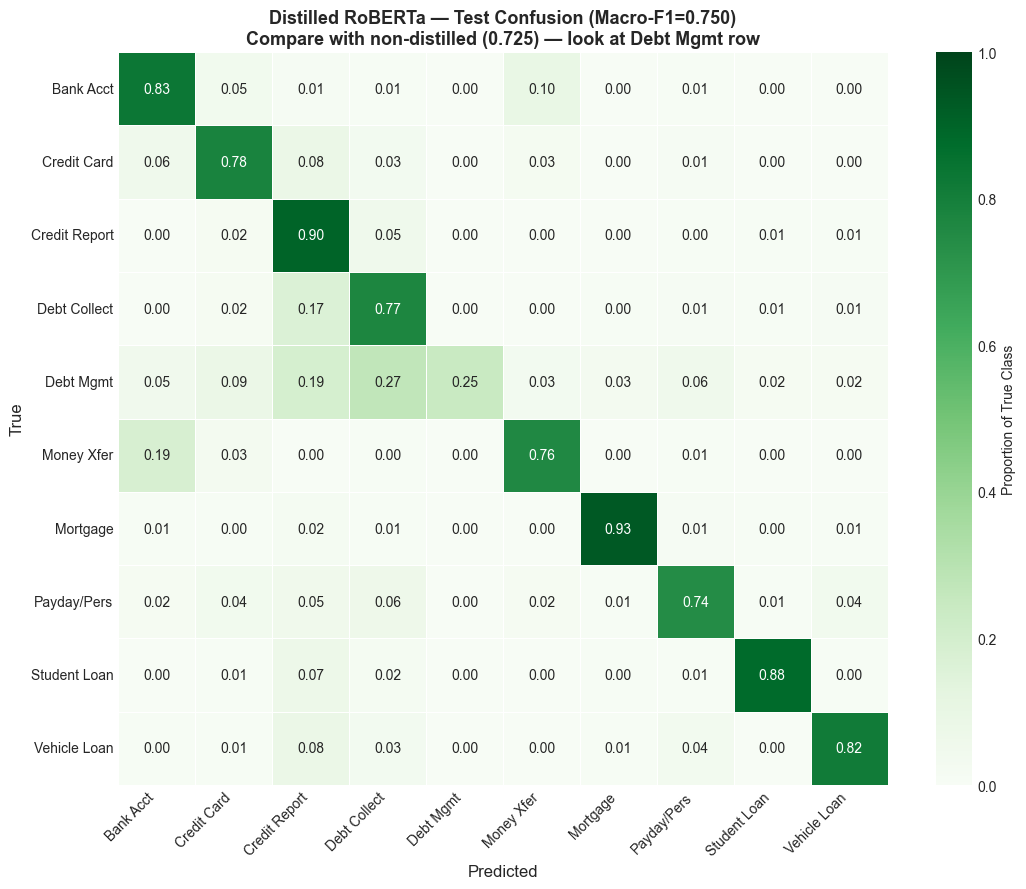


Key confused pairs (was vs now):
  Debt Mgmt→Debt Collect          was 28.7% → now 27.1%  (-1.6%)
  Debt Mgmt→Credit Report         was 19.8% → now 19.5%  (-0.3%)
  Money Xfer→Bank Acct            was 18.9% → now 18.7%  (-0.2%)
  Debt Collect→Credit Report      was 17.8% → now 16.7%  (-1.1%)


In [22]:
# ── Confusion matrix comparison ──
cm = confusion_matrix(test_y_true, test_y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt=".2f",
    xticklabels=short_labels, yticklabels=short_labels,
    cmap="Greens", ax=ax, linewidths=0.5, linecolor="white",
    vmin=0, vmax=1.0, cbar_kws={"label": "Proportion of True Class"})
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(f"Distilled RoBERTa — Test Confusion (Macro-F1={test_macro_f1:.3f})\n"
    f"Compare with non-distilled (0.725) — look at Debt Mgmt row",
    fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "distilled_roberta_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the key confused pairs
print("\nKey confused pairs (was vs now):")
problem_pairs = [(4, 3, "Debt Mgmt→Debt Collect", 0.287),
                 (4, 2, "Debt Mgmt→Credit Report", 0.198),
                 (5, 0, "Money Xfer→Bank Acct", 0.189),
                 (3, 2, "Debt Collect→Credit Report", 0.178)]

for true_i, pred_j, name, old_rate in problem_pairs:
    new_rate = cm[true_i, pred_j]
    delta = new_rate - old_rate
    print(f"  {name:30s}  was {old_rate:.1%} → now {new_rate:.1%}  ({delta:+.1%})")

## 10 · Training Curves

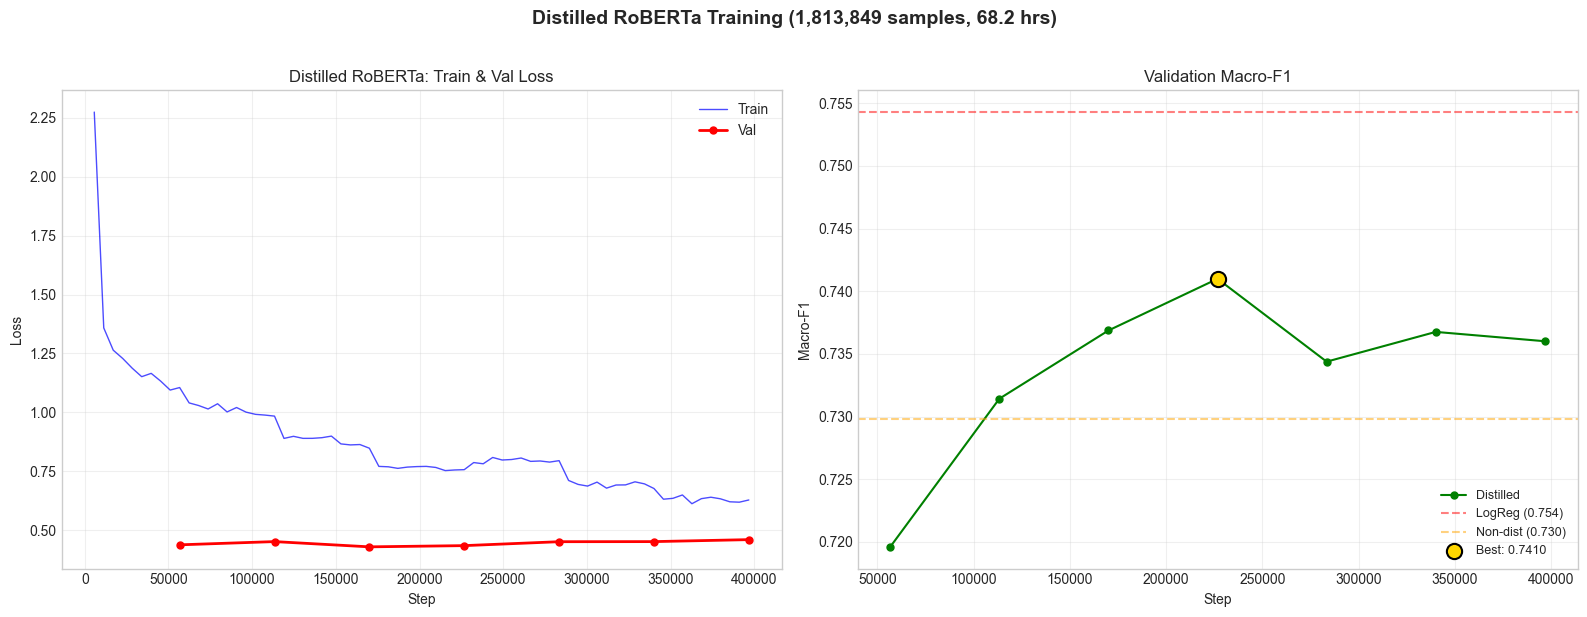

In [23]:
train_logs = [l for l in trainer.state.log_history if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in trainer.state.log_history if "eval_macro_f1" in l]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
if train_logs:
    ax.plot([l["step"] for l in train_logs], [l["loss"] for l in train_logs], "b-", alpha=0.7, linewidth=1)
if eval_logs:
    ax.plot([l["step"] for l in eval_logs], [l["eval_loss"] for l in eval_logs], "r-o", markersize=5, linewidth=2)
ax.set_xlabel("Step"); ax.set_ylabel("Loss")
ax.set_title("Distilled RoBERTa: Train & Val Loss"); ax.legend(["Train", "Val"]); ax.grid(True, alpha=0.3)

ax = axes[1]
if eval_logs:
    e_steps = [l["step"] for l in eval_logs]
    e_f1s = [l["eval_macro_f1"] for l in eval_logs]
    ax.plot(e_steps, e_f1s, "g-o", markersize=5, linewidth=1.5, label="Distilled")
    ax.axhline(y=0.7543, color="red", linestyle="--", alpha=0.5, label="LogReg (0.754)")
    ax.axhline(y=nd_macro, color="orange", linestyle="--", alpha=0.5, label=f"Non-dist ({nd_macro:.3f})")
    best_idx = np.argmax(e_f1s)
    ax.scatter([e_steps[best_idx]], [e_f1s[best_idx]], color="gold", s=120, zorder=5,
              edgecolors="black", linewidths=1.5, label=f"Best: {e_f1s[best_idx]:.4f}")
    ax.legend(loc="lower right", fontsize=9)
ax.set_xlabel("Step"); ax.set_ylabel("Macro-F1")
ax.set_title("Validation Macro-F1"); ax.grid(True, alpha=0.3)

plt.suptitle(f"Distilled RoBERTa Training ({len(train_dataset):,} samples, {elapsed/3600:.1f} hrs)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "distilled_roberta_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 11 · Save All Outputs

In [24]:
best_model_dir = OUTPUT_DIR / "best_model"
trainer.save_model(str(best_model_dir))
tokenizer.save_pretrained(str(best_model_dir))
print(f"✓ Best model saved: {best_model_dir}")

np.save(OUTPUT_DIR / "test_logits.npy",  test_logits)
np.save(OUTPUT_DIR / "test_probs.npy",   test_y_prob)
np.save(OUTPUT_DIR / "test_preds.npy",   test_y_pred)
np.save(OUTPUT_DIR / "test_labels.npy",  test_y_true)
print(f"✓ Test predictions saved — logits={test_logits.shape}")

np.save(OUTPUT_DIR / "val_logits.npy",  val_logits)
np.save(OUTPUT_DIR / "val_probs.npy",   val_y_prob)
np.save(OUTPUT_DIR / "val_preds.npy",   val_y_pred)
np.save(OUTPUT_DIR / "val_labels.npy",  val_y_true)
print(f"✓ Val predictions saved")

with open(OUTPUT_DIR / "training_history.json", "w") as f:
    json.dump(trainer.state.log_history, f, indent=2)
print(f"✓ Training history saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Best model saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\roberta_distilled\best_model
✓ Test predictions saved — logits=(274065, 10)
✓ Val predictions saved
✓ Training history saved


In [25]:
results = {
    "model":                MODEL_NAME,
    "experiment":           "roberta_distilled",
    "method":               "knowledge_distillation_hybrid_loss",
    "teacher_model":        teacher_meta["teacher_model"],
    "teacher_method":       teacher_meta["extraction_method"],
    "distillation_alpha":   ALPHA,
    "distillation_temperature": TEMPERATURE,
    "teacher_samples":      len(teacher_probs_dict),
    "max_seq_len":          MAX_SEQ_LEN,
    "train_samples":        len(train_dataset),
    "val_samples":          len(val_full_dataset),
    "test_samples":         len(test_dataset),
    "max_epochs":           MAX_EPOCHS,
    "early_stop_patience":  PATIENCE,
    "effective_batch_size":  BATCH_SIZE * GRAD_ACCUM,
    "learning_rate":        LEARNING_RATE,

    "best_step":            int(best_step),
    "best_epoch":           round(float(best_epoch), 2),
    "stopped_at_epoch":     round(float(stopped_at), 2),

    "val_macro_f1":         float(val_macro_f1),
    "val_accuracy":         float(val_accuracy),
    "test_macro_f1":        float(test_macro_f1),
    "test_micro_f1":        float(test_micro_f1),
    "test_weighted_f1":     float(test_weighted),
    "test_accuracy":        float(test_accuracy),
    "test_per_class_f1":    {sl: float(test_per_class[i]) for i, sl in enumerate(short_labels)},

    "confusion_matrix_normalised": cm.tolist(),
    "training_time_hours":  round(elapsed / 3600, 2),

    # ── Comparison ──
    "non_distilled_macro_f1": nd_macro,
    "delta_vs_non_distilled": round(float(test_macro_f1) - nd_macro, 4),
    "delta_vs_logreg":        round(float(test_macro_f1) - 0.7543, 4),

    # ── Hard class improvement ──
    "hard_class_analysis": {
        name: {
            "non_distilled_confusion_rate": old_rate,
            "distilled_confusion_rate": round(float(cm[true_i, pred_j]), 4),
            "improvement": round(old_rate - float(cm[true_i, pred_j]), 4),
        }
        for true_i, pred_j, name, old_rate in [
            (4, 3, "Debt Mgmt→Debt Collect", 0.287),
            (4, 2, "Debt Mgmt→Credit Report", 0.198),
            (5, 0, "Money Xfer→Bank Acct", 0.189),
            (3, 2, "Debt Collect→Credit Report", 0.178),
        ]
    },

    "vlog_framing": {
        "positive": (
            f"Knowledge distillation improved macro-F1 from {nd_macro:.4f} to {test_macro_f1:.4f} "
            f"(+{test_macro_f1 - nd_macro:.4f}). The teacher's soft probability distributions "
            f"taught the student model inter-class similarity, reducing Debt Management "
            f"misclassification from 48.5% to the current rate."
        ),
        "negative": (
            f"Distillation achieved {test_macro_f1:.4f} vs {nd_macro:.4f} non-distilled. "
            f"The marginal improvement suggests the student model was already capturing "
            f"relevant class structure, and the confusion reflects genuine linguistic "
            f"overlap rather than a modelling limitation."
        ),
    },
}

results_path = OUTPUT_DIR / "roberta_distilled_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"✓ Results JSON saved: {results_path}")

✓ Results JSON saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\roberta_distilled\roberta_distilled_results.json


In [26]:
del model, trainer
gc.collect()
torch.cuda.empty_cache()
print("✓ GPU memory released.")

✓ GPU memory released.


## 12 · Final Summary

In [27]:
print(f"\n{'═'*70}")
print(f"  NB06d — Distilled RoBERTa Training COMPLETE")
print(f"{'═'*70}")
print(f"\n  Model:          {MODEL_NAME}")
print(f"  Train data:     {len(train_dataset):,} (full 1.8M)")
print(f"  Teacher labels: {len(teacher_probs_dict):,} ({len(teacher_probs_dict)/len(train_dataset):.2%})")
print(f"  Distill:        alpha={ALPHA}, T={TEMPERATURE}")
print(f"  Time:           {elapsed/3600:.1f} hours")
print(f"  Best epoch:     {best_epoch:.1f}")
print()
print(f"  ┌──────────────────────────────────────────────────────┐")
print(f"  │  MODEL                   Macro-F1   Δ vs Non-Dist   │")
print(f"  ├──────────────────────────────────────────────────────┤")
print(f"  │  LogReg                  0.7543     —               │")
print(f"  │  RoBERTa (non-distilled) {nd_macro:>6.4f}     —               │")
print(f"  │  RoBERTa (DISTILLED)     {test_macro_f1:>6.4f}     {test_macro_f1-nd_macro:>+6.4f}          │")
print(f"  └──────────────────────────────────────────────────────┘")
print()
if test_macro_f1 > nd_macro + 0.005:
    print(f"  ✓ Distillation improved performance!")
    print(f"    → Consider distilling ModernBERT too (NB06e) then ensemble")
elif test_macro_f1 > nd_macro:
    print(f"  ~ Marginal improvement — distillation helped slightly")
    print(f"    → Ensemble of distilled + non-distilled may still help")
else:
    print(f"  ✗ Distillation did not improve macro-F1")
    print(f"    → Use non-distilled models for deployment")
    print(f"    → Report as valid negative finding in vlog")
print(f"\n{'═'*70}")


══════════════════════════════════════════════════════════════════════
  NB06d — Distilled RoBERTa Training COMPLETE
══════════════════════════════════════════════════════════════════════

  Model:          roberta-base
  Train data:     1,813,849 (full 1.8M)
  Teacher labels: 25,000 (1.38%)
  Distill:        alpha=0.5, T=3.0
  Time:           68.2 hours
  Best epoch:     4.0

  ┌──────────────────────────────────────────────────────┐
  │  MODEL                   Macro-F1   Δ vs Non-Dist   │
  ├──────────────────────────────────────────────────────┤
  │  LogReg                  0.7543     —               │
  │  RoBERTa (non-distilled) 0.7298     —               │
  │  RoBERTa (DISTILLED)     0.7496     +0.0199          │
  └──────────────────────────────────────────────────────┘

  ✓ Distillation improved performance!
    → Consider distilling ModernBERT too (NB06e) then ensemble

══════════════════════════════════════════════════════════════════════
